In [3]:
import matplotlib.pyplot as plt
import numpy as np

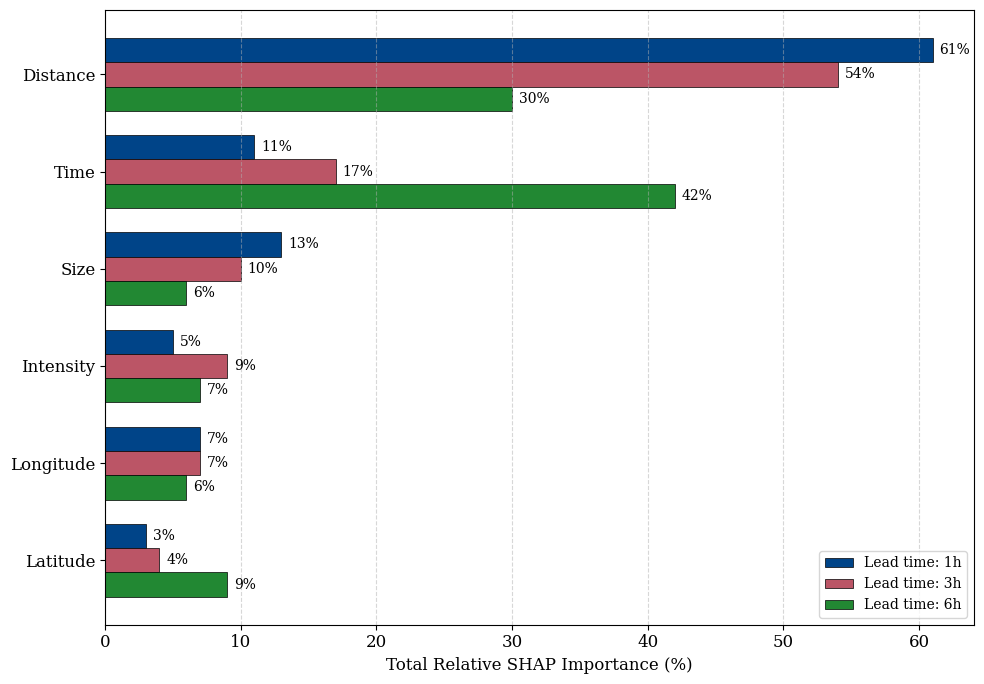

In [6]:
# Use serif font for publication
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12

# Data
features = ['Intensity', 'Distance', 'Size', 'Longitude', 'Latitude', 'Time']

# SHAP values (rounded first)
shap_1h_raw = np.array([5, 61.1, 13.1, 7.2, 2.6, 11])
shap_3h_raw = np.array([8.6, 53.5, 10.1, 6.8, 4.5, 16.6])
shap_6h_raw = np.array([7.3, 29.6, 6, 5.6, 9.4, 42.0])

# Round before everything
shap_1h = np.round(shap_1h_raw).astype(int)
shap_3h = np.round(shap_3h_raw).astype(int)
shap_6h = np.round(shap_6h_raw).astype(int)

# Total importance for sorting
total_importance = shap_1h + shap_3h + shap_6h

# Sort features by total importance (descending)
sort_idx = np.argsort(-total_importance)
features_sorted = np.array(features)[sort_idx]
shap_1h_sorted = shap_1h[sort_idx]
shap_3h_sorted = shap_3h[sort_idx]
shap_6h_sorted = shap_6h[sort_idx]

# Bar positions
y = np.arange(len(features))
bar_height = 0.25

plt.figure(figsize=(10, 7))

# Plot horizontal grouped bars: 1h on top, 3h middle, 6h bottom
plt.barh(y - bar_height, shap_1h_sorted, height=bar_height, color='#004488',
         edgecolor='black', linewidth=0.5, label='Lead time: 1h')
plt.barh(y, shap_3h_sorted, height=bar_height, color='#BB5566',
         edgecolor='black', linewidth=0.5, label='Lead time: 3h')
plt.barh(y + bar_height, shap_6h_sorted, height=bar_height, color='#228833',
         edgecolor='black', linewidth=0.5, label='Lead time: 6h')

plt.yticks(y, features_sorted)
plt.gca().invert_yaxis()  # <-- Most important feature on top

plt.xlabel("Total Relative SHAP Importance (%)")
plt.legend(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Annotate bars
for i in range(len(features)):
    for dy, val in zip([-bar_height, 0, bar_height], [shap_1h_sorted[i], shap_3h_sorted[i], shap_6h_sorted[i]]):
        plt.text(val + 0.5, y[i] + dy, f"{val}%", va='center', fontsize=10)

plt.tight_layout()
plt.show()
